HASIL KLASIFIKASI DECISION TREE
              precision    recall  f1-score   support

           0       0.74      0.96      0.83        52
           1       0.82      0.33      0.47        27

    accuracy                           0.75        79
   macro avg       0.78      0.65      0.65        79
weighted avg       0.76      0.75      0.71        79



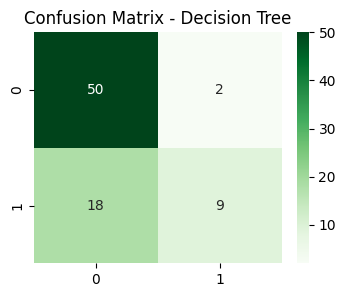

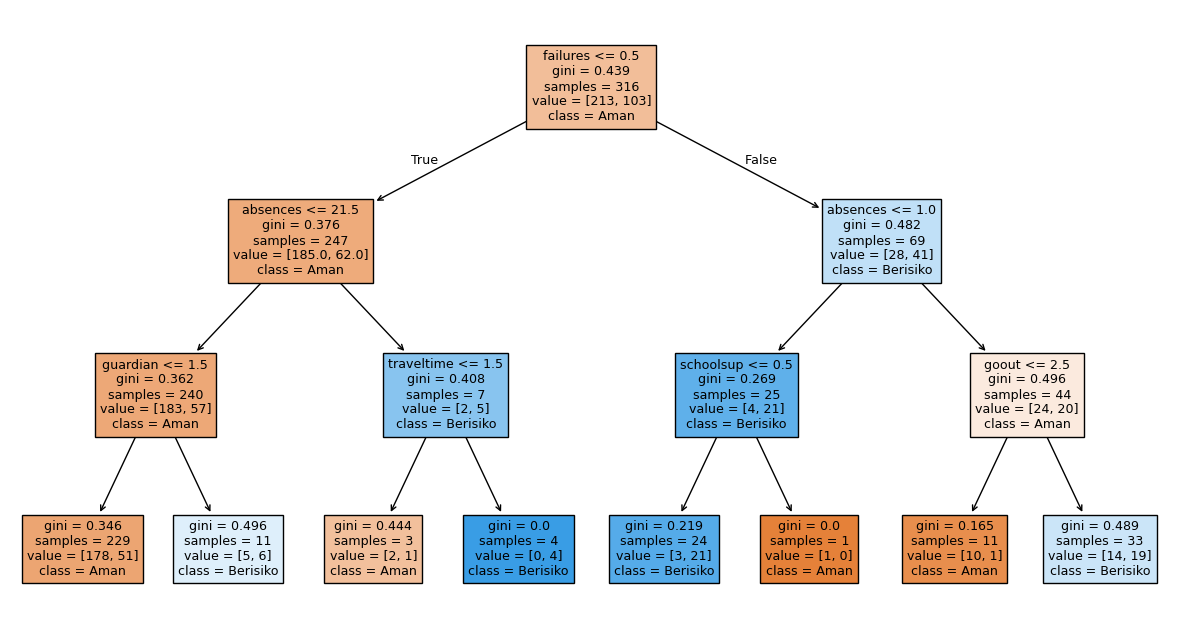

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

df = pd.read_excel('Book1.xlsx')
df['Label'] = np.where(df['G3'] < 10, 1, 0)
df_model = df.drop(['G1', 'G2', 'G3'], axis=1)
le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Label', axis=1)
y = df_model['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_dt = DecisionTreeClassifier(random_state=42, max_depth=3)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

print("HASIL KLASIFIKASI DECISION TREE")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(4,3))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

plt.figure(figsize=(15,8))
plot_tree(model_dt, feature_names=X.columns, class_names=['Aman', 'Berisiko'], filled=True)
plt.show()